## **SUMMARY**
This script is used to create a footprint-level inventory using all locally-obtained data sources from Hayward. Steps include addressing within-source and between-source disagreements, imputing and inferring gaps, and exporting to R2D-compatible format. 

### **PREREQUISITES**
0_Inventory_Preprocessing.ipynb

1_Attribute_to_Ftpt_Local.ipynb


In [1]:
# Copyright (c) 2025, Meredith Lochhead
# All rights reserved.
#
# This source code is licensed under the BSD 3-Clause License found in the
# LICENSE file in the root directory of this source tree.

In [2]:
# # NOTE: 
# Local_Flag indicates whether or not local data (i.e. tax parcel or address point) is present in the data. 
# Local_Flag 1, 2, and 3 indicate different cases, and Local_Flag 0 indicates no data associated with footprint. 

In [3]:
# Relevant python functions
import numpy as np
import pandas as pd
import geopandas as gpd
import random
import matplotlib.pyplot as plt
import folium 
import os 
import sys
import contextily as ctx

# BRAILS functions for imputation 
from brails.types.image_set import ImageSet    
from brails.types.asset_inventory import Asset, AssetInventory
from brails.utils import Importer


# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)
import functions_local as inv_local
import functions_national as inv_natl
import functions_general as fxns
import functions_inference as infr


In [4]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]

In [5]:
# Target Directory 
directory = './Inventory_Outputs/Synthesized_Local/'
name = 'Synthesized_Local' # This will be the name of the inventory within the R2D folder

# Make directory and intermediate directory
os.makedirs(directory, exist_ok=True)
dir_generation = directory + 'InventoryGeneration/'
dir_attribution = directory + 'FootprintAttribution/'
dir_r2d = './R2D_Analysis/Inventories/' + name + '/'
os.makedirs(dir_generation, exist_ok=True)
os.makedirs(dir_r2d, exist_ok=True)


In [6]:
## Set flag to plot data sources for each feature
plot_sources = True 

## **SECTION 1: Select and Prioritize Building Features**

In [7]:
# Load Data
inv_raw = fxns.json_to_gdf(dir_attribution + 'All_Local_Data_Attributed.json', crs_main)

# Create modifiable instance of raw inventory 
inv_mod = inv_raw.copy()

### **Address Within-Source Disagreement for Local Data Sources**

In [8]:
# Load Zoning Data to be used as prioritization method 
zoning = gpd.read_file('./Input_Data/Local/Hayward_Zoning.geojson')
zoning = zoning.to_crs(crs_main)
zoning = zoning[['ZONING_REPORT','ZONING_','ZONING_DETAIL','PD_Type','geometry']]

# Join with merged tax/NSI inventory 
inventory_zoning = inv_mod.sjoin(zoning, how='left')
inventory_zoning = inventory_zoning.drop_duplicates(subset=["FootprintID"], keep = 'first')
inv_mod = inventory_zoning.copy()

In [9]:
# COLUMNS THAT ARE MODIFIED TO HAVE A SINGLE VALUE RATHER THAN A LIST  
modified_to_single_solo = ['Num_Stories', 'Bldg_Area']
for col in modified_to_single_solo:
    inv_mod[col + '_Single']  = inv_mod[col].apply(inv_natl.modify_to_single_val)

# Assign paired selections for building class and construction 
inv_mod[['BldgClass_Single', 'Construction_Single']] = inv_mod[['Bldg_Class', 'Construction']].apply(inv_natl.modify_to_single_val_paired, axis=1).apply(pd.Series)

# Assign paired selections for year built and effective year built 
inv_mod[['YearBuilt_Single', 'EffYearBuilt_Single']] = inv_mod[['Year_Built', 'Eff_Year_Built']].apply(inv_natl.modify_to_single_val_paired, axis=1).apply(pd.Series)

# Apply function to map occupancy class values
inv_mod['Tax_UseDescription_Hazus_Single'] = inv_mod[['Use_Description_Hazus','ZONING_REPORT']].apply(inv_local.modify_to_single_tax_occupancy, axis = 1)
inv_mod['Address_FeatureCode_Hazus_Single'] = inv_mod[['FC_Hazus','ZONING_REPORT']].apply(inv_local.modify_to_single_tax_occupancy, axis = 1)
    

### **Address Disagreement Between Data Sources**

#### YEAR BUILT

Year Built Priority List: 

1. Effective year built (with unreasonable values screened out) - assumed to be most reflective of seismic performace
2. Year built (with unreasonable values screened out)


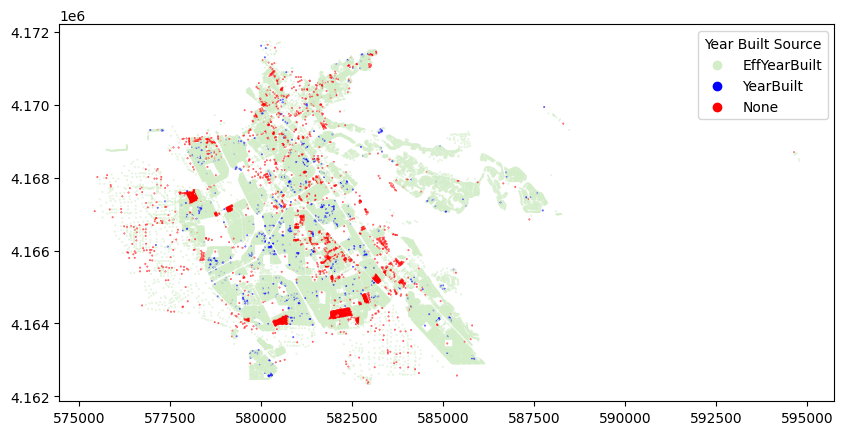

In [10]:
# Remove extremely old points (one point has eff year built of 1062 - seem like typos of "1062" instead of "1962")
drop_idx = inv_mod[(inv_mod['EffYearBuilt_Single']<1700) | (inv_mod['EffYearBuilt_Single']>2026)].index
inv_mod.loc[drop_idx, 'EffYearBuilt_Single'] = np.nan
drop_idx = inv_mod[(inv_mod['YearBuilt_Single']<1700) | (inv_mod['YearBuilt_Single']>2026)].index
inv_mod.loc[drop_idx, 'YearBuilt_Single'] = np.nan

# Create combined row with best estimate of year built 
# Set highest priority field available for given footprint

inv_mod['Year_Best'] = inv_mod.apply(
    lambda row: row['EffYearBuilt_Single'] if pd.notna(row['EffYearBuilt_Single']) 
    else (row['YearBuilt_Single'] if pd.notna(row['YearBuilt_Single']) 
    else np.nan), axis=1
)

# Create combined row with source of best estimate year 
inv_mod['Year_Best_Source'] = inv_mod.apply(
    lambda row: 'EffYearBuilt' if pd.notna(row['EffYearBuilt_Single']) 
        else ('YearBuilt' if pd.notna(row['YearBuilt_Single']) 
        else ('None')), axis=1
)

# Plot sources 
if plot_sources: 
    
    ## PLOT INFORMATION SOURCE 
    inv_mod2 = inv_mod[~((inv_mod['Local_Flag']==0))].copy()

    # Define a color map based on the unique values in your column
    unique_values = ['EffYearBuilt', 'YearBuilt', 'None']
    color_map = {value: color for value, color in zip(unique_values, ['#d2edc7', 'blue', 'red'])}

    # Map colors to the column values
    inv_mod2['color'] = inv_mod2['Year_Best_Source'].map(color_map)

    # Plot the GeoDataFrame
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.plot(ax=ax, color=inv_mod2['color'], markersize = .1)

    # Add legend
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Year Built Source')  # Replace with an appropriate title

    plt.show()


#### NUMBER OF STORIES - No prioritization needed, only data cleaning

In [11]:
# No prioritization needed because only one source available 

# Create appropriate column 
inv_mod['Stories_Best'] = inv_mod['Num_Stories_Single']

# Remove cases in tax data where number of stories is listed as 0
inv_mod.loc[inv_mod[inv_mod['Stories_Best'] == 0].index, 'Stories_Best'] = np.nan


#### NUMBER OF UNITS

Number of Units Priority List: 

1. Number of address points in a building footprint - based on spot checking and observations in Hayward, this is the most robust way to determine number of units 
2. Tax Parcel number of units - these sometimes get split/combined across and within footprints, so are slightly less preferred


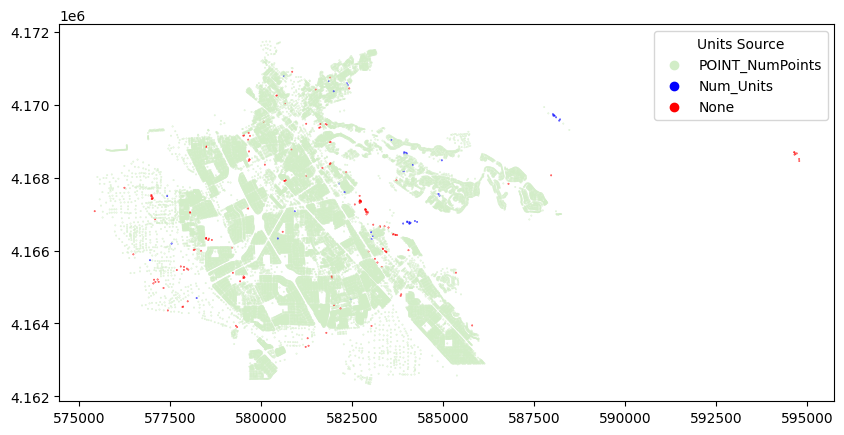

In [12]:
# Set highest priority field available for given footprint

# Remove cases in tax data where number of address points is listed as 0
inv_mod.loc[inv_mod[inv_mod['POINT_NumPoints'] == 0].index, 'POINT_NumPoints'] = np.nan
inv_mod.loc[inv_mod[inv_mod['Num_Units'] == 0].index, 'Num_Units'] = np.nan


inv_mod['Units_Best'] = inv_mod.apply(
    lambda row: row['POINT_NumPoints'] if pd.notna(row['POINT_NumPoints']) 
    else (row['Num_Units'] if pd.notna(row['Num_Units']) 
    else (np.nan)), axis=1
)

inv_mod['Units_Best_Source'] = inv_mod.apply(
    lambda row: 'POINT_NumPoints' if pd.notna(row['POINT_NumPoints']) 
    else ('Num_Units' if pd.notna(row['Num_Units']) 
    else ('None')), axis=1)


#  Plot sources 
if plot_sources: 
   
    ## PLOT INFORMATION SOURCE 
    inv_mod2 = inv_mod[~((inv_mod['Local_Flag']==0))].copy()

    # Define a color map based on the unique values in your column
    unique_values = ['POINT_NumPoints', 'Num_Units', 'None']
    color_map = {value: color for value, color in zip(unique_values, ['#d2edc7', 'blue', 'red'])}

    # Map colors to the column values
    inv_mod2['color'] = inv_mod2['Units_Best_Source'].map(color_map)

    # Plot the GeoDataFrame
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.plot(ax=ax, color=inv_mod2['color'], markersize = .1)

    # Add legend
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Units Source') 

    plt.show()




#### PLAN AREA

Plan Area Priority List: 

1. Tax Building Area divided by Number of Stories 
2. Footprint Geometry Area 


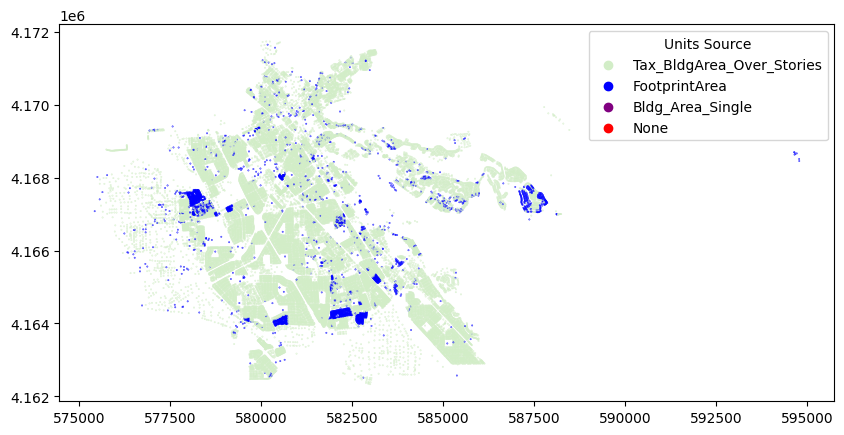

In [13]:
# Remove cases in tax data where number of address points is listed as 0
inv_mod.loc[inv_mod[inv_mod['Bldg_Area_Single'] == 0].index, 'Bldg_Area_Single'] = np.nan
inv_mod.loc[inv_mod[inv_mod['FootprintArea'] == 0].index, 'FootprintArea'] = np.nan

# Modify all RES2 strucutres in tax data to have one story 
inv_mod.loc[inv_mod[inv_mod['Address_FeatureCode_Hazus_Single'] == 'RES2'].index, 'Stories_Best'] = 1


# Set highest priority field available for given footprint
# Assign plan area 
inv_mod['PlanArea_Best'] = inv_mod.apply(
    lambda row: (row['Bldg_Area_Single'] / row['Stories_Best']) if (pd.notna(row['Bldg_Area_Single']) and pd.notna(row['Stories_Best']))
    else (row['FootprintArea'] if pd.notna(row['FootprintArea']) 
    else ((row['Bldg_Area_Single'] if pd.notna(row['Bldg_Area_Single']) else np.nan))), axis=1)

inv_mod['PlanArea_Best_Source'] = inv_mod.apply(
    lambda row: 'Tax_BldgArea_Over_Stories' if (pd.notna(row['Bldg_Area_Single']) and pd.notna(row['Stories_Best']))
    else ('FootprintArea' if pd.notna(row['FootprintArea']) 
    else (('Bldg_Area_Single' if pd.notna(row['Bldg_Area_Single']) 
    else ('None')))), axis=1)


#  Plot sources 
if plot_sources: 

    ## PLOT INFORMATION SOURCE 

    inv_mod2 = inv_mod[~((inv_mod['Local_Flag']==0))].copy()

    # Define a color map based on the unique values in your column
    unique_values = ['Tax_BldgArea_Over_Stories', 'FootprintArea', 'Bldg_Area_Single', 'None']
    color_map = {value: color for value, color in zip(unique_values, ['#d2edc7', 'blue', 'purple', 'red'])}

    # Map colors to the column values
    inv_mod2['color'] = inv_mod2['PlanArea_Best_Source'].map(color_map)

    # Plot the GeoDataFrame
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.plot(ax=ax, color=inv_mod2['color'], markersize = .1)

    # Add legend
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Units Source') 

    plt.show()


#### OCCUPANCY CLASS

Occupancy Class Priority List: 

1. Designate all RES1 cases where address and parcel boths ay RES1 
2. Address Feature Code (seems to be reliable based on spot checking and specificity to given unit, rather than a parcel, which may contain multiple footprints)
3. Tax Use Description 


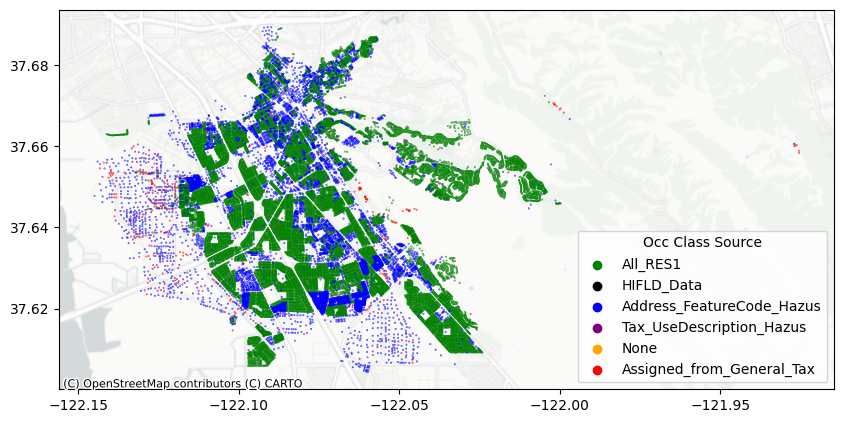

In [16]:
## CLEAN CASES BASED ON NOTBLDG, UNK, AND _VAC TAX DATA 
inv_mod = inv_local.clean_supplemental_occ(inv_mod.copy())

# Pre-set tracking column to None
inv_mod['OccupancyClass_Best_Source'] = 'None'

# For cases with all three sources calling it a RES1, label as RES1 and reset number of units to 1
all_res1 = inv_mod[(inv_mod['Tax_UseDescription_Hazus_Single'] == inv_mod['Address_FeatureCode_Hazus_Single']) & (inv_mod['Address_FeatureCode_Hazus_Single'] == 'RES1')]
inv_mod.loc[all_res1.index,'OccupancyClass_Best'] = inv_mod.loc[all_res1.index,'Address_FeatureCode_Hazus_Single'].values
inv_mod.loc[all_res1.index,'OccupancyClass_Best_Source'] = 'All_RES1'
inv_mod.loc[all_res1.index,'Units_Best'] = 1
inv_mod.loc[all_res1.index,'Units_Best_Source'] = 'Updated_by_OccClass'

# Assign occupancy class to generic assignments
inv_mod = inv_local.assign_generic_tax_missing(inv_mod, ['IND',''], [1, 2, 3, 4, 5, 6]) # Extra '' here means that empty things get assigned randomly as industrial
inv_mod = inv_local.assign_generic_tax_missing(inv_mod, ['COM'], [1, 2, 3, 4, 5, 7, 8, 9, 10]) # Not including hospitals as an option 
inv_mod = inv_local.assign_generic_tax_missing(inv_mod, ['RES'], [3]) # Only including multifamily residential 

# Find remaining points and drop uncertain points
remaining = inv_mod[inv_mod['OccupancyClass_Best_Source']=='None']
remaining.loc[remaining[remaining['Address_FeatureCode_Hazus_Single'].isin(['IND', 'COM', 'RES'])].index, 'Address_FeatureCode_Hazus_Single'] = ''
remaining.loc[remaining[remaining['Tax_UseDescription_Hazus_Single'].isin(['IND', 'COM', 'RES'])].index, 'Tax_UseDescription_Hazus_Single'] = ''

# Update using prioritization
inv_mod.loc[remaining.index, 'OccupancyClass_Best'] = remaining.apply(
    lambda row: row['Address_FeatureCode_Hazus_Single'] if (row['Address_FeatureCode_Hazus_Single']!='') 
    else (row['Tax_UseDescription_Hazus_Single'] if (row['Tax_UseDescription_Hazus_Single']!='') 
    else np.nan), axis=1)

inv_mod.loc[remaining.index,'OccupancyClass_Best_Source'] = remaining.apply(
    lambda row: 'Address_FeatureCode_Hazus' if (row['Address_FeatureCode_Hazus_Single']!='') 
    else ('Tax_UseDescription_Hazus' if (row['Tax_UseDescription_Hazus_Single']!='') 
    else 'None'), axis=1)

# Update occupancy class based on best estimate of number of units 
inv_mod['OccupancyClass_Best'] = inv_mod['OccupancyClass_Best'].fillna('')
inv_mod['OccupancyClass_Best'] = inv_mod.apply(infr.update_res_occ, axis=1)


#  Plot sources 
if plot_sources: 
    
    ## PLOT INFORMATION SOURCE 
    inv_mod2 = inv_mod[~((inv_mod['Local_Flag']==0))].copy()

    # Define a color map based on the unique values in your column
    unique_values = ['All_RES1', 'HIFLD_Data', 'Address_FeatureCode_Hazus', 'Tax_UseDescription_Hazus', 'None','Assigned_from_General_Tax']
    color_map = {value: color for value, color in zip(unique_values, ['green', 'black', 'blue', 'purple', 'orange', 'red'])}

    # Map colors to the column values
    inv_mod2['color'] = inv_mod2['OccupancyClass_Best_Source'].map(color_map)

    # Plot the GeoDataFrame
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.to_crs(crs_plot).plot(ax=ax, color=inv_mod2['color'], markersize = .1)
    ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

    # Add legend
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Occ Class Source') 

    plt.show()



#### BUILDING TYPE

Building Type Priority List: 

1. All RES2 buildings designated as building type H, regardless of data
2. Remove cases of steel and concrete in RES1, RES3A, RES3B -- this is likely incorrect 
2. Otherwise, use tax construction designation from parcel data 

In [ ]:
inv_mod.columns

Index(['geometry', 'Address_ID', 'FeatureCode', 'CensusBlock', 'CensusTract',
       'FC_Hazus', 'FootprintID', 'POINT_ID', 'POINT_NumPoints',
       'POINT_MergeFlag', 'POINT_Source', 'APN_PQ', 'Use_Description',
       'Use_Code', 'Landslide', 'Liquefaction', 'Fault_Zone', 'Total_Value',
       'Improvement_Value', 'Homeowner_Exemption', 'Year_Built',
       'Eff_Year_Built', 'Bldg_Class', 'Construction', 'Bldg_Condition',
       'Bldg_Quality', 'Bldg_Area', 'Num_Bldg', 'Num_Units', 'Num_Stories',
       'Parking', 'Use_Description_Hazus', 'Construction_Hazus', 'Num_Parcels',
       'FootprintArea', 'FootprintHeight', 'ftpt_geometry', 'Footprint_Flag',
       'Local_Flag', 'index_right', 'ZONING_REPORT', 'ZONING_',
       'ZONING_DETAIL', 'PD_Type', 'Num_Stories_Single', 'Bldg_Area_Single',
       'BldgClass_Single', 'Construction_Single', 'YearBuilt_Single',
       'EffYearBuilt_Single', 'Tax_UseDescription_Hazus_Single',
       'Address_FeatureCode_Hazus_Single', 'Year_Best', 'Year

In [18]:

# For all buildings with best estimate of occupancy as RES2, reset to type H
inv_mod.loc[inv_mod[inv_mod['OccupancyClass_Best']=='RES2'].index, 'Construction_Single'] = 'H'

# For all buildings with best estimate of occupancy as RES2, reset to 1 story - very small number are equal to 2, vast majority are 1 or missing 
inv_mod.loc[inv_mod[inv_mod['OccupancyClass_Best']=='RES2'].index, 'Stories_Best'] = 1

# For RES1, RES3A, and RES3B, if a structure is listed as steel or concrete, reset to np.nan - this is likely incorrect 
inv_mod.loc[inv_mod[(inv_mod['OccupancyClass_Best'].isin(['RES1','RES3A','RES3B'])) & (inv_mod['Construction_Single'].isin(['S', 'C']))].index, 'Construction_Single'] = np.nan


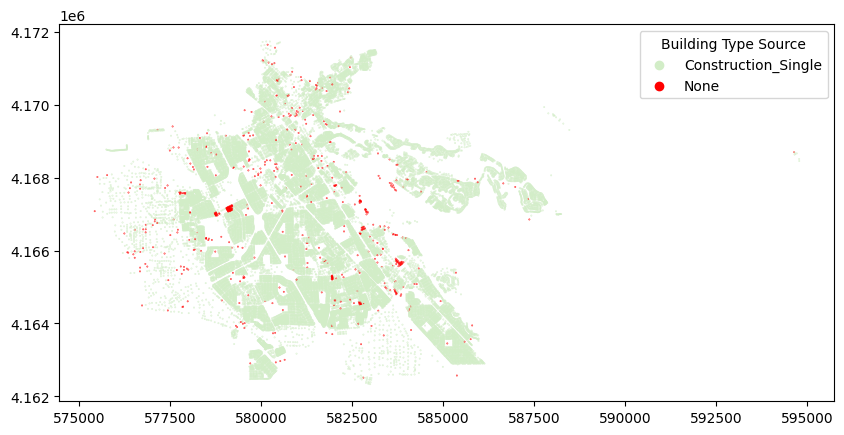

In [19]:
# Create combined row with best estimate of building type
inv_mod['BuildingType_Best'] = inv_mod.apply(
    lambda row: row['Construction_Single'] if pd.notna(row['Construction_Single']) 
    else (np.nan), axis=1)

# Create combined row with source of best estimate year 
inv_mod['BuildingType_Best_Source'] = inv_mod.apply(
    lambda row: 'Construction_Single' if pd.notna(row['Construction_Single']) 
        else ('None'), axis=1)


#  Plot sources 
if plot_sources: 

    ## PLOT INFORMATION SOURCE 

    inv_mod2 = inv_mod[~((inv_mod['Local_Flag']==0))].copy()

    # Define a color map based on the unique values in your column
    unique_values = ['Construction_Single', 'None']
    color_map = {value: color for value, color in zip(unique_values, ['#d2edc7', 'red'])}

    # Map colors to the column values
    inv_mod2['color'] = inv_mod2['BuildingType_Best_Source'].map(color_map)

    # Plot the GeoDataFrame
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.plot(ax=ax, color=inv_mod2['color'], markersize = .1)

    # Add legend
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Building Type Source') 

    plt.show()



#### REPLACEMENT COST USING HAZUS

Replacement Cost Priority List: 

1. Replacement cost computed using Hazus values and building square footage
2. Tax imporvement value -- depends on when the building was last sold, etc. Potentailly more variable, and thus not prioritized. 

In [20]:
# Load Hazus cost values 
hazus_conversion = pd.read_csv('./Input_Data/National/Hazus_Cost.csv')

# Compute hazus replacement cost
inv_mod = infr.compute_hazus_replacement_cost(inv_mod.copy(), hazus_conversion)

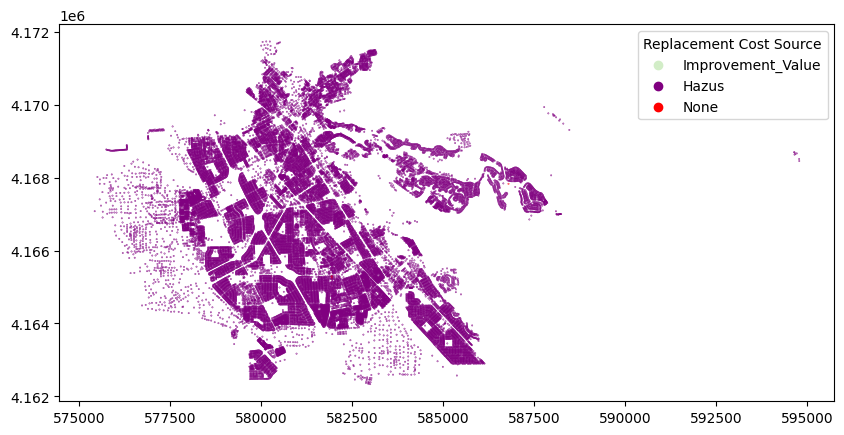

In [21]:
# Remove cases in tax data where value is listed as 0
inv_mod.loc[inv_mod[inv_mod['Improvement_Value'] == 0].index, 'Improvement_Value'] = np.nan

# Set highest priority field available for given footprint
# Prioritization Order: ReplacementCost_Hazus, Improvement_Value - NOTE: Improvement_Value is not normalized and depends on when the house was most recently sold 

# Prioritize tax values, then Hazus-computed replacement cost
inv_mod['ReplacementCost_Best'] = inv_mod.apply(
    lambda row: row['ReplacementCost_Hazus'] if pd.notna(row['ReplacementCost_Hazus']) 
    else (row['Improvement_Value'] if pd.notna(row['Improvement_Value']) 
    else (np.nan)), axis=1
)

inv_mod['ReplacementCost_Best_Source'] = inv_mod.apply(
    lambda row: 'Hazus' if pd.notna(row['ReplacementCost_Hazus']) 
    else ('Improvement_Value' if pd.notna(row['Improvement_Value']) 
    else ('None')), axis=1
)

#  Plot sources 
if plot_sources: 

    ## PLOT INFORMATION SOURCE 

    inv_mod2 = inv_mod[~((inv_mod['Local_Flag']==0))].copy()

    # Define a color map based on the unique values in your column
    unique_values = ['Improvement_Value', 'Hazus', 'None']
    color_map = {value: color for value, color in zip(unique_values, ['#d2edc7', 'purple', 'red'])}

    # Map colors to the column values
    inv_mod2['color'] = inv_mod2['ReplacementCost_Best_Source'].map(color_map)

    # Plot the GeoDataFrame
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.plot(ax=ax, color=inv_mod2['color'], markersize = .1)

    # Add legend
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Replacement Cost Source') 

    plt.show()


### **Export**

In [ ]:
# Save
inv_natl.gdf_to_json(inv_mod,dir_generation + 'Inventory_AllFields.json')

JSON File Saved


## **SECTION 2: Prepare File for Imputation**

In [ ]:
# Load best estimate inventory 
data = inv_natl.json_to_gdf(dir_generation + 'Inventory_AllFields.json', crs_main)

# Remove cases of footprints with no data 
data = data[data['Local_Flag']!=0]

# Remove cases with no occupancy class (only two instances for Hayward tax data)
length = len(data)
data = data[data['OccupancyClass_Best']!='']
print(length - len(data), 'points dropped due to missing occupancy class')

# Convert to format of R2D - keep missing data (for imputation purposes)
for_imputation = data.copy().to_crs(crs_plot)
for_imputation['Longitude'] = for_imputation['geometry'].x
for_imputation['Latitude'] = for_imputation['geometry'].y

# Separate required columns for imputation 
for_imputation = for_imputation[['Latitude','Longitude','PlanArea_Best','Stories_Best','Year_Best','ReplacementCost_Hazus','ReplacementCost_Best','OccupancyClass_Best', 'BuildingType_Best','Units_Best','CensusBlock','CensusTract','FootprintID']]

# Standardize columns for imputation and R2D 
for_imputation = for_imputation.rename(columns={
    'PlanArea_Best' : 'PlanArea',
    'Stories_Best': 'NumberOfStories',
    'Year_Best': 'YearBuilt',
    'OccupancyClass_Best': 'OccupancyClass',
    'BuildingType_Best':'BuildingType',
    'ReplacementCost_Best':'ReplacementCost',
    'Units_Best':'NumberOfUnits'})

# Convert None for imputation types 
for_imputation['BuildingType'] = for_imputation['BuildingType'].replace('None', np.nan)

# Add index
for_imputation.insert(0, 'index', range(len(for_imputation)))

for_imputation.to_csv(dir_generation + 'Inventory_Before_Imputation.csv', index = False)

0 points dropped due to missing occupancy class


## **SECTION 3: Impute Data**

In [ ]:
# Specify data for imputation
file_path = directory + 'InventoryGeneration/Inventory_Before_Imputation.csv'

# create an Import to get the classes
importer = Importer()
knn_imputer_class = importer.get_class("KnnImputer")

# Load inventory 
inventory = AssetInventory()
inventory.read_from_csv(file_path,keep_existing=True, id_column='index') 

# Print example of assets 
inventory.get_asset_features(86)[1]  # empty or 'NA' are missing values
# First number is building index, [1] narrows down to just data 

No existing inventory found. Reading in the new inventory from the file.


{'index': 86,
 'PlanArea': 2086.0,
 'NumberOfStories': 1.0,
 'YearBuilt': 1949.0,
 'ReplacementCost_Hazus': 280713.01999999996,
 'ReplacementCost': 280713.01999999996,
 'OccupancyClass': 'RES3A',
 'BuildingType': 'Wood',
 'NumberOfUnits': 2.0,
 'CensusBlock': 60014372004006,
 'CensusTract': 6001437200,
 'FootprintID': 93.0,
 'type': 'building'}

In [ ]:
# Imput data
imputer=knn_imputer_class(inventory,n_possible_worlds=1, exclude_features=['PlanArea','ReplacementCost','OccupancyClass','FootprintID','BuildingType'])
new_inventory = imputer.impute()

# print('\n\nExample Imptued Row Output')
# new_inventory.get_asset_features(86)[1]  # empty or 'NA' are missing values

/Users/mialochhead/Documents/GitHub/Building_Inventory_Generation/inventory_env/lib/python3.10/site-packages/brails/imputers/knn_imputer/knn_imputer.py:158: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bldg_properties_df = bldg_properties_df.replace("", np.nan, inplace=False)


Missing percentages among 34186 assets
NumberOfStories: 3.46%
YearBuilt: 7.78%
ReplacementCost_Hazus: 0.02%
NumberOfUnits: 0.44%
CensusBlock: 0.56%
CensusTract: 0.56%
Primitive imputation done.
Running the main imputation. This may take a while.
Enumerating clusters: 20 among 69
Enumerating clusters: 40 among 69
Enumerating clusters: 60 among 69
Done imputation. It took 0.00 mins


In [ ]:
# Conver to pandas geodataframe
inv_geoj = new_inventory.get_geojson()
gdf = gpd.GeoDataFrame.from_features(inv_geoj["features"])

## SAVE IMPUTED INVENTORY
inv_natl.gdf_to_json(gdf, directory + 'InventoryGeneration/Inventory_IMPUTED.json')


JSON File Saved


## **SECTION 4: Infer Structure Type**

In [ ]:
# Load best estimate inventory 
data = inv_natl.json_to_gdf(dir_generation + 'Inventory_IMPUTED.json', crs_main)


In [ ]:
# SET FLAG 
use_bldg_type = True # Use building type (material) to constrain list of possible structure types  
allow_mh_only_for_res2 = True # Allows structure type 'MH' only when the occupancy class is RES2 (diverges from Hazus) 
no_urm = True # Doesn't allow the assignment of URM buildings, due to efforts to retrofit those buildings (diverges from Hazus)
res3ab_to_res1_flag = True # Adopts structure types used for 'RES1' to be assigned for RES3A and RES3B. 2-4 unit structures are likely structurally more similar to single family homes than to large apartment buildings. 

# SET VARIABLE NAMESTrue
state = 'California'
occ_key = 'OccupancyClass'
nstory_key = 'NumberOfStories'
year_key = 'YearBuilt'
strtype_key = 'StructureType'
bldgtype_key = 'BuildingType'
n_pw = 1

# CALL FUNCTION TO INFER STRUCTURE TYPE
bldg_properties_df = infr.infer_structure_type(data.copy(), state, occ_key, nstory_key, year_key, bldgtype_key, strtype_key, n_pw, use_bldg_type, allow_mh_only_for_res2, no_urm, res3ab_to_res1_flag)


## REPEAT IMPUTATION PROCESS AND REMOVE BUILDING TYPES THAT ARE MISSING HAZUS FRAGILITY FUNCTIONS 
alldata = bldg_properties_df.copy()
missing_structuretype = bldg_properties_df[((alldata['StructureType'].isna()) | (alldata['StructureType']=='na'))].copy()
has_structuretype = bldg_properties_df[~((alldata['StructureType'].isna()) | (alldata['StructureType']=='na'))].copy()

# Check if any data lost
if len(missing_structuretype) + len(has_structuretype) != len(alldata):
    raise ValueError('Data Lost')

# SET FLAGS
use_bldg_type = False # Use building type (material) to constrain list of possible structure types  
allow_mh_only_for_res2 = True # Allows structure type 'MH' only when the occupancy class is RES2 (diverges from Hazus) 
no_urm = True # Doesn't allow the assignment of URM buildings, due to efforts to retrofit those buildings (diverges from Hazus)
res3ab_to_res1_flag = True # Adopts structure types used for 'RES1' to be assigned for RES3A and RES3B. 2-4 unit structures are likely structurally more similar to single family homes than to large apartment buildings. 


# CALL FUNCTION TO INFER STRUCTURE TYPE
bldg_properties_df = infr.infer_structure_type(missing_structuretype.copy(), state, occ_key, nstory_key, year_key, bldgtype_key, strtype_key, n_pw, use_bldg_type, allow_mh_only_for_res2, no_urm, res3ab_to_res1_flag)

# Recombine dataframes 
recombined_gdf = gpd.GeoDataFrame(pd.concat([has_structuretype, bldg_properties_df], ignore_index=True))

# Check if any data lost
if len(recombined_gdf) != len(alldata):
    raise ValueError('Data Lost')

# EXPORT
inv_natl.gdf_to_json(recombined_gdf, dir_generation + 'Inventory_IMPUTED_With_StructureType.json')

CHECK: Regions considered in structure type assignment: ['West Coast']
HAZUS does not provide structural type information for West Coast-EDU1-mid_rise-1950_to_1970-None
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-EDU1-mid_rise-post_1970-None
Num Buildings in that Class: 1
CHECK: Regions considered in structure type assignment: ['West Coast']
HAZUS does not provide structural type information for West Coast-EDU1-mid_rise-1950_to_1970
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-EDU1-mid_rise-post_1970
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-COM1-high_rise-1950_to_1970
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-COM1-high_rise-post_1970
Num Buildings in that Class: 1
JSON File Saved


## **SECTION 5: Export for R2D**

In [ ]:
# Convert to format of R2D - remove missing data (for test run only)
bldg_properties_df_nomissing = recombined_gdf[~((recombined_gdf['StructureType'].isna()) | (recombined_gdf['StructureType']=='na'))].copy()
print(len(recombined_gdf[((recombined_gdf['StructureType'].isna()) | (recombined_gdf['StructureType']=='na'))].copy()), 'points dropped due to missing structure type')

# Create appropriate columns
r2d = bldg_properties_df_nomissing.copy()
r2d['Longitude'] = r2d['geometry'].x
r2d['Latitude'] = r2d['geometry'].y
r2d = r2d[['Latitude','Longitude','PlanArea','NumberOfStories','YearBuilt','ReplacementCost','ReplacementCost_Hazus','StructureType','BuildingType','OccupancyClass_clean','OccupancyClass','NumberOfUnits','CensusBlock','CensusTract', 'FootprintID','geometry']]

# Assign design level and height class (used in regional analysis)
r2d = infr.find_design_level(r2d, 'StructureType', 'YearBuilt', 'DesignLevel')
r2d = infr.find_height_class(r2d, 'StructureType', 'NumberOfStories', 'HeightClass')

# Add id
r2d.insert(0, 'id', range(len(r2d)))

# Rename occupancy class columns for R2D use
r2d = r2d.rename(columns={'OccupancyClass': 'OccupancyClass_Actual',
                          'OccupancyClass_clean': 'OccupancyClass'})

# Save inventory
r2d.to_csv(dir_r2d + 'R2D_Inventory.csv', index = False)
inv_natl.gdf_to_json(r2d, dir_r2d + 'R2D_Inventory.json')

# Randomly sample for R2D test run 
sampled_df = r2d.sample(n=50, random_state=1, replace = False)
sampled_df = sampled_df.drop(columns='id')
sampled_df.insert(0, 'id', range(len(sampled_df)))
sampled_df.to_csv(dir_r2d + 'R2D_Inventory_SAMPLED.csv', index = False)

4 points dropped due to missing structure type
JSON File Saved


In [ ]:
# #### UNCOMMENT TO CHECK FOR GAPS IN R2D INVENTORY
# # Only BuildingType and HeightClass should possibly have missing data

# for col in r2d.columns: 
#     print(col)
    
#     if len(r2d[r2d[col].isna()]) > 0:
#         print('\n\nDATA WITH ISNA:', col, len(r2d[r2d[col].isna()]),'\n\n')
#     if len(r2d[r2d[col]=='']) > 0:
#         print('\n\nDATA WITH "":',col, len(r2d[r2d[col]=='']),'\n\n')
#     if len(r2d[r2d[col]=='None']) > 0:
#         print('\n\nDATA WITH None:',col, len(r2d[r2d[col]=='']),'\n\n')
#     if len(r2d[r2d[col]=='na']) > 0:
#         print('\n\nDATA WITH na:',col, len(r2d[r2d[col]=='']),'\n\n')